In [11]:
import matplotlib.pyplot as plt
import pandas as pd

import soundscapy as sspy
from soundscapy.databases import isd  # araus

# Working with Soundscape Databases in Soundscapy

## Introduction

Soundscapy provides access to several standardized soundscape databases, making it easy to work with soundscape survey data from different sources. This tutorial will guide you through the process of loading, exploring, and analyzing data from these databases.

### Learning Objectives

By the end of this tutorial, you will be able to:
- Load data from different soundscape databases
- Understand the structure and content of each database
- Perform data validation and quality checks
- Filter and select data based on various criteria
- Work with multi-language data
- Apply common analysis techniques to soundscape data

Let's begin by exploring the available databases in Soundscapy.

## 1. Available Databases in Soundscapy

Soundscapy currently provides access to the following databases:

1. **International Soundscape Database (ISD)**: A collection of soundscape survey data from various locations around the world, following the ISO 12913 standard.

2. **Soundscape Attributes Translation Project (SATP)**: A database containing translations of soundscape attributes in multiple languages, allowing for cross-cultural soundscape research.

3. **ARAUS Database**: A database of soundscape surveys conducted in the Augmented Reality Audio for Urban Soundscapes project.

Each database has its own module in Soundscapy, providing specialized functions for loading, validating, and analyzing the data.

## 2. Working with the International Soundscape Database (ISD)

The International Soundscape Database (ISD) is a comprehensive collection of soundscape survey data following the ISO 12913 standard. It includes data from various locations, with perceptual attributes, acoustic metrics, and contextual information.

### 2.1 Loading the ISD Data

In [12]:
# Load the ISD dataset
isd_data = isd.load()

# Display basic information about the dataset
print(f"ISD Dataset shape: {isd_data.shape}")
print(f"Number of locations: {isd_data['LocationID'].nunique()}")
print(f"Number of records: {isd_data['RecordID'].nunique()}")

# Display the first few rows
isd_data.head()

ISD Dataset shape: (3589, 142)
Number of locations: 26
Number of records: 2664


,LocationID,SessionID,GroupID,RecordID,start_time,end_time,latitude,longitude,Language,Survey_Version,...,RA_cp90_Max,RA_cp95_Max,THD_THD_Max,THD_Min_Max,THD_Max_Max,THD_L5_Max,THD_L10_Max,THD_L50_Max,THD_L90_Max,THD_L95_Max
0,CarloV,CarloV2,2CV12,1434,2019-05-16 18:46:00,2019-05-16 18:56:00,37.17685,-3.590392,eng,engISO2018,...,8.15,6.72,-0.09,-11.76,54.18,34.82,26.53,5.57,-9.0,-10.29
1,CarloV,CarloV2,2CV12,1435,2019-05-16 18:46:00,2019-05-16 18:56:00,37.17685,-3.590392,eng,engISO2018,...,8.15,6.72,-0.09,-11.76,54.18,34.82,26.53,5.57,-9.0,-10.29
2,CarloV,CarloV2,2CV13,1430,2019-05-16 19:02:00,2019-05-16 19:12:00,37.17685,-3.590392,eng,engISO2018,...,5.00,3.91,-2.10,-19.32,72.52,32.33,24.52,0.25,-16.3,-17.33
3,CarloV,CarloV2,2CV13,1431,2019-05-16 19:02:00,2019-05-16 19:12:00,37.17685,-3.590392,eng,engISO2018,...,5.00,3.91,-2.10,-19.32,72.52,32.33,24.52,0.25,-16.3,-17.33
4,CarloV,CarloV2,2CV13,1432,2019-05-16 19:02:00,2019-05-16 19:12:00,37.17685,-3.590392,eng,engISO2018,...,5.00,3.91,-2.10,-19.32,72.52,32.33,24.52,0.25,-16.3,-17.33


### 2.2 Understanding the ISD Data Structure

The ISD dataset contains several types of columns:

1. **Index Columns**: Identify the survey, location, and respondent
   - `LocationID`: Identifier for the location
   - `RecordID`: Identifier for the audio recording
   - `GroupID`: Identifier for the group of respondents
   - `SessionID`: Identifier for the survey session

2. **Perceptual Attribute Questions (PAQs)**: Ratings on a 5-point Likert scale
   - `PAQ1` (pleasant): How pleasant is the soundscape?
   - `PAQ2` (vibrant): How vibrant is the soundscape?
   - `PAQ3` (eventful): How eventful is the soundscape?
   - `PAQ4` (chaotic): How chaotic is the soundscape?
   - `PAQ5` (annoying): How annoying is the soundscape?
   - `PAQ6` (monotonous): How monotonous is the soundscape?
   - `PAQ7` (uneventful): How uneventful is the soundscape?
   - `PAQ8` (calm): How calm is the soundscape?

3. **Acoustic Metrics**: Objective measurements of the sound environment
   - `LAeq`: A-weighted equivalent continuous sound level
   - Various other metrics like `N5`, `Sharpness`, etc.

4. **Contextual Information**: Additional data about the survey context
   - Weather conditions, time of day, etc.

Let's explore the distribution of PAQ responses:

/var/folders/6t/7h8wn9n92w5f24ml_bkwck9m0000gn/T/ipykernel_21400/2381964797.py:3: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  paq_distribution = isd_data[paq_columns].apply(pd.value_counts).T


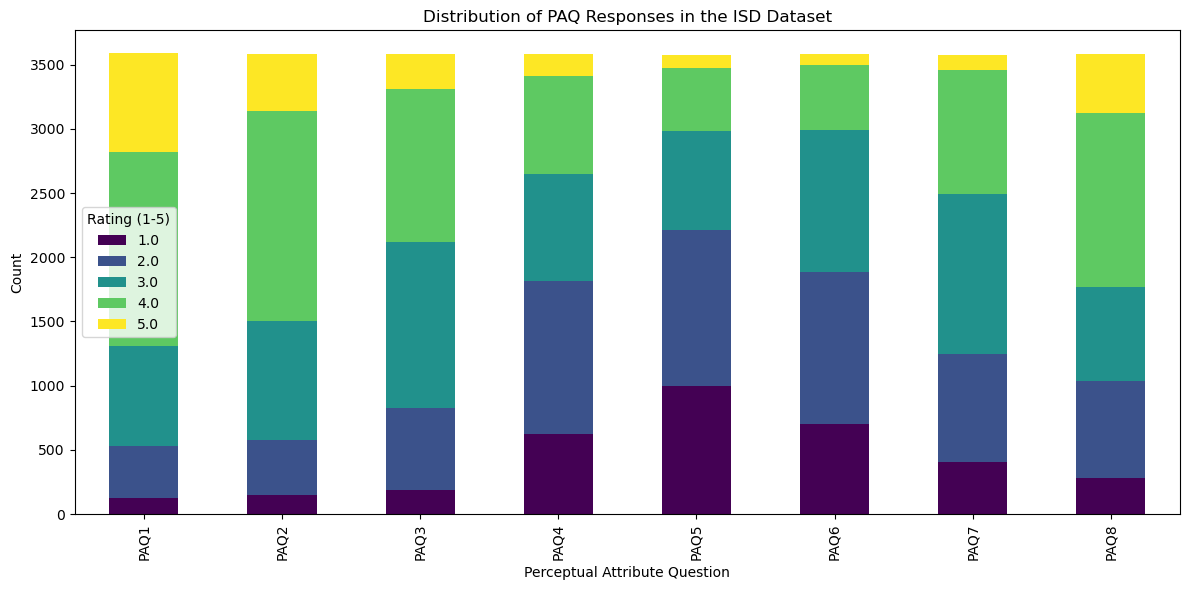

In [13]:
# Calculate the distribution of responses for each PAQ
paq_columns = [f"PAQ{i}" for i in range(1, 9)]
paq_distribution = isd_data[paq_columns].apply(pd.value_counts).T

# Create a stacked bar chart
ax = paq_distribution.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6),
    colormap="viridis",
    title="Distribution of PAQ Responses in the ISD Dataset",
)
ax.set_xlabel("Perceptual Attribute Question")
ax.set_ylabel("Count")
ax.legend(title="Rating (1-5)")
plt.tight_layout()
plt.show()

### 2.3 Validating the ISD Data

Before analyzing the data, it's important to validate it to ensure quality and consistency. Soundscapy provides functions for validating the ISD data:

In [28]:
# Validate the ISD dataset
valid_data, invalid_indices = isd.validate(isd_data)

# Display validation results
print(f"Original dataset size: {len(isd_data)}")
print(f"Valid dataset size: {len(valid_data)}")
print(
    f"Number of invalid records: {len(invalid_indices) if isinstance(invalid_indices, pd.DataFrame) else 0}"
)

# If there are invalid records, display the first few
if isinstance(invalid_indices, pd.DataFrame):
    print("\nSample of invalid records:")
isd_data.iloc[invalid_indices[:5].index]

Original dataset size: 3589
Valid dataset size: 3533
Number of invalid records: 56

Sample of invalid records:


,LocationID,SessionID,GroupID,RecordID,start_time,end_time,latitude,longitude,Language,Survey_Version,...,RA_cp90_Max,RA_cp95_Max,THD_THD_Max,THD_Min_Max,THD_Max_Max,THD_L5_Max,THD_L10_Max,THD_L50_Max,THD_L90_Max,THD_L95_Max
6,CarloV,CarloV2,2CV21,1428,2019-05-16 18:39:00,2019-05-16 18:49:00,37.17685,-3.590392,eng,engISO2018,...,4.45,3.52,-1.91,-13.06,65.17,29.99,22.06,2.14,-9.60,-11.12
9,CarloV,CarloV2,2CV32,1437,2019-05-16 18:56:00,2019-05-16 19:00:00,37.17685,-3.590392,eng,engISO2018,...,6.06,4.93,-0.57,-16.16,58.38,32.16,24.88,3.93,-13.25,-14.21
13,CarloV,CarloV2,2CV32,1441,2019-05-16 18:56:00,2019-05-16 19:00:00,37.17685,-3.590392,eng,engISO2018,...,6.06,4.93,-0.57,-16.16,58.38,32.16,24.88,3.93,-13.25,-14.21
30,CarloV,CarloV2,2CV62,1418,2019-05-16 19:20:00,2019-05-16 19:30:00,37.17685,-3.590392,eng,engISO2018,...,8.88,7.33,-1.22,-9.39,72.49,38.63,30.30,10.19,-5.72,-6.94
32,CarloV,CarloV2,2CV62,1420,2019-05-16 19:20:00,2019-05-16 19:30:00,37.17685,-3.590392,eng,engISO2018,...,8.88,7.33,-1.22,-9.39,72.49,38.63,30.30,10.19,-5.72,-6.94


The validation process checks for several issues:

1. **Missing Values**: Ensures that all required fields have values
2. **Valid PAQ Responses**: Checks that PAQ responses are within the valid range (1-5)
3. **Consistent Responses**: Identifies respondents who gave the same rating for all PAQs
4. **Data Integrity**: Verifies that the data structure matches the expected format

### 2.4 Calculating ISO Coordinates

The ISO 12913 standard defines a circumplex model for soundscape perception, with two main dimensions: pleasantness and eventfulness. Soundscapy can calculate these coordinates from the PAQ responses:

In [15]:
# Calculate ISO coordinates if not already present
if "ISOPleasant" not in valid_data.columns or "ISOEventful" not in valid_data.columns:
    valid_data = sspy.surveys.add_iso_coords(valid_data)

# Display the first few rows with ISO coordinates
valid_data[
    [
        "LocationID",
        "PAQ1",
        "PAQ2",
        "PAQ3",
        "PAQ4",
        "PAQ5",
        "PAQ6",
        "PAQ7",
        "PAQ8",
        "ISOPleasant",
        "ISOEventful",
    ]
].head()

,LocationID,PAQ1,PAQ2,PAQ3,PAQ4,PAQ5,PAQ6,PAQ7,PAQ8,ISOPleasant,ISOEventful
0,CarloV,2.0,4.0,2.0,1.0,2.0,2.0,4.0,2.0,0.219670,-0.133883
1,CarloV,2.0,4.0,4.0,4.0,4.0,4.0,1.0,1.0,-0.426777,0.530330
2,CarloV,5.0,3.0,3.0,1.0,2.0,1.0,3.0,4.0,0.676777,-0.073223
3,CarloV,5.0,3.0,3.0,1.0,2.0,2.0,3.0,4.0,0.603553,-0.146447
4,CarloV,5.0,3.0,3.0,2.0,2.0,3.0,3.0,4.0,0.457107,-0.146447


### 2.5 Filtering and Selecting Data

Soundscapy provides functions for filtering and selecting data from the ISD dataset:

Data for CamdenTown:
Number of records: 105
Mean ISOPleasant: -0.103
Mean ISOEventful: 0.364


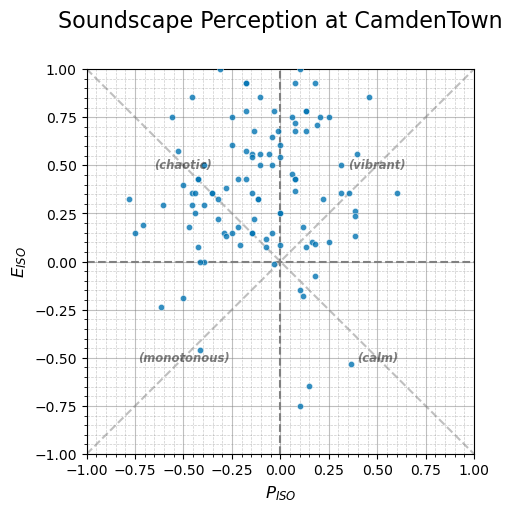

In [16]:
# Select data for a specific location
location_id = "CamdenTown"
location_data = isd.select_location_ids(valid_data, location_id)

print(f"Data for {location_id}:")
print(f"Number of records: {len(location_data)}")
print(f"Mean ISOPleasant: {location_data['ISOPleasant'].mean():.3f}")
print(f"Mean ISOEventful: {location_data['ISOEventful'].mean():.3f}")

# Visualize the location data
ax = sspy.scatter(
    location_data,
    title=f"Soundscape Perception at {location_id}",
    diagonal_lines=True,
)
plt.show()

You can also select data based on other criteria, such as `RecordID`, `GroupID`, or `SessionID`:

In [17]:
# Select data for a specific record
record_id = "CT101"
record_data = valid_data[valid_data["RecordID"] == record_id]

print(f"Data for Record {record_id}:")
print(f"Number of responses: {len(record_data)}")
print(f"Mean ISOPleasant: {record_data['ISOPleasant'].mean():.3f}")
print(f"Mean ISOEventful: {record_data['ISOEventful'].mean():.3f}")

Data for Record CT101:
Number of responses: 0
Mean ISOPleasant: nan
Mean ISOEventful: nan


### 2.6 Comparing Multiple Locations

One common analysis is to compare soundscape perceptions across different locations:

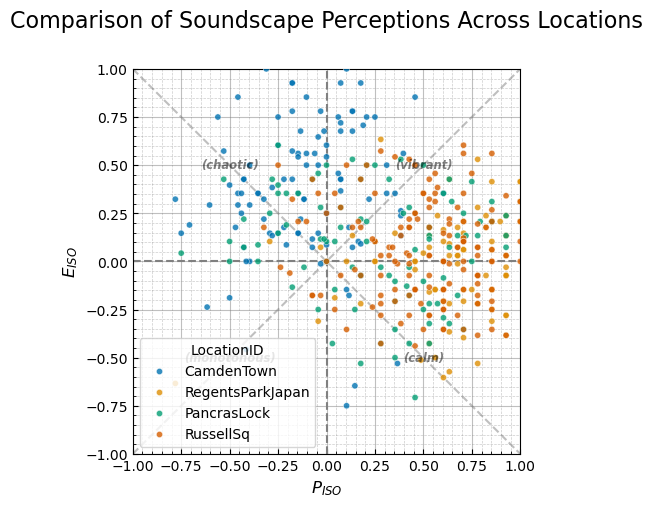

In [18]:
# Select data for multiple locations
locations = ["CamdenTown", "RegentsParkJapan", "PancrasLock", "RussellSq"]
multi_location_data = pd.concat(
    [isd.select_location_ids(valid_data, loc) for loc in locations]
)

# Create a scatter plot with locations as hue
ax = sspy.scatter(
    multi_location_data,
    title="Comparison of Soundscape Perceptions Across Locations",
    hue="LocationID",
    diagonal_lines=True,
)
plt.show()

## 3. Working with the Soundscape Attributes Translation Project (SATP)

The Soundscape Attributes Translation Project (SATP) provides translations of soundscape attributes in multiple languages. This is particularly useful for cross-cultural soundscape research.

### 3.1 Loading the SATP Data

Accessing and loading the SATP data is done through `soundscapy.databases.satp`, which provides functions for loading the SATP dataset from Zenodo.

In [19]:
from soundscapy.databases import satp

data = satp.load_zenodo()
data.head()

,Language,Institution,Recording,Participant,Age,Gender,PAQ1,PAQ2,PAQ3,PAQ4,PAQ5,PAQ6,PAQ7,PAQ8,loud,sequence_id
0,alb,UBT,CG01,UBT_P1,21,Female,90.0,32.0,30.0,8.0,7.0,5.0,4.0,53.0,55.0,NaN
1,alb,UBT,CG01,UBT_P2,20,Female,60.0,58.0,62.0,16.0,41.0,34.0,31.0,66.0,42.0,NaN
2,alb,UBT,CG01,UBT_P3,21,Female,66.0,45.0,61.0,2.0,4.0,3.0,5.0,12.0,55.0,NaN
3,alb,UBT,CG01,UBT_P4,21,Female,90.0,70.0,75.0,10.0,2.0,5.0,0.0,41.0,55.0,NaN
4,alb,UBT,CG01,UBT_P5,20,Female,95.0,21.0,97.0,7.0,0.0,7.0,9.0,29.0,51.0,NaN


#### The SATP Analysis Module in Soundscapy

Soundscapy's `satp` module is not a data loader — it provides the **CircE structural equation model** for validating circumplex structure in soundscape data. It requires `soundscapy[r]`.

The main entry point is `fit_circe()`:

In [20]:
# | output: false

import soundscapy as sspy

# Fit all four circumplex model types to your data:
eng_data = data.query("Language == 'eng'")
results = sspy.satp.fit_circe(eng_data, language="eng", datasource="UCL")

Date: Mon May 11 00:32:34 2026 
Data: Circumplex Estimation 
Model:Unconstrained model 
Reference variable at 0 degree: PAQ1 



/var/folders/6t/7h8wn9n92w5f24ml_bkwck9m0000gn/T/ipykernel_21400/4107017985.py:7: UserWarning: The SATP analysis module is experimental. Use with caution.
  results = sspy.satp.fit_circe(eng_data, language="eng", datasource="UCL")



              MEASURES OF FIT OF THE MODEL  

-----------Sample discrepancy function value        : 0.088 

-----------Population discrepancy function value, Fo 
           Point estimate                           : 0.076
           Confidence Interval 90 %                 : ( 0.049 ; 0.112 ) 

-----------ROOT MEAN SQUARE ERROR OF APPROXIMATION 
           Steiger-Lind: RMSEA=sqrt(Fo/Df) 
           Point estimate                           : 0.087
           Confidence Interval 90 %                 : ( 0.07 ; 0.106 ) 

-----------Discrepancy function TEST 
           TEST STATISTIC                           : 75.86
           p values:
           Ho: perfect fit (RMSEA=0.00)             : 0
           Ho: close fit (RMSEA=0.050)              : 0

-----------Power estimation (alpha=0.05),
           N 864
           Degrees of freedom= 10
           Effective number of parameters= 26
       Ho (RMSEA=0.05) vs Alternative (RMSEA=0.01) : 0.871
       Ho (RMSEA=0.05) vs Alternative (RMSEA

In [21]:
results

,datasource,language,model,n,m,chisq,d,p,cfi,gfi,...,rmsea_u,gdiff,PAQ1,PAQ2,PAQ3,PAQ4,PAQ5,PAQ6,PAQ7,PAQ8
0,UCL,eng,unconstrained,864,3,75.855189,10,3.242280e-12,0.988,0.981,...,0.106,9.07,0.0,45.0,94.0,138.0,175.0,229.0,274.0,339.0
1,UCL,eng,equal_ang,864,3,534.252188,17,1.132686e-102,0.903,0.869,...,0.202,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,UCL,eng,equal_com,864,3,370.055529,17,3.299241e-68,0.934,0.907,...,0.169,9.49,0.0,46.0,94.0,138.0,177.0,231.0,275.0,340.0
3,UCL,eng,circumplex,864,3,830.648941,24,6.912095e-160,0.848,0.811,...,0.209,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


For language-specific coordinate angles from the SATP project, see the `LANGUAGE_ANGLES` constant below.

### 3.2 Understanding the SATP Data Structure

The SATP dataset contains translations of soundscape attributes in multiple languages. Each row represents a translation of a specific attribute in a specific language.

The main columns are:

1. **Language**: The language of the translation
2. **Attribute**: The soundscape attribute being translated
3. **Translation**: The translated term
4. **Back Translation**: The back-translation to English
5. **Notes**: Additional notes about the translation

### 3.3 Working with Language-Specific Angles

Different languages may have slightly different semantic relationships between soundscape attributes. Soundscapy provides language-specific angles for the circumplex model:

In [22]:
# Display the language-specific angles
from soundscapy.surveys import LANGUAGE_ANGLES

print("Language-specific angles for the circumplex model:")
for language, angles in LANGUAGE_ANGLES.items():
    print(f"{language}: {angles}")

Language-specific angles for the circumplex model:
eng: (0, 46, 94, 138, 177, 241, 275, 340)
arb: (0, 36, 45, 135, 167, 201, 242, 308)
cmn: (0, 18, 38, 154, 171, 196, 217, 318)
hrv: (0, 84, 93, 160, 173, 243, 273, 354)
nld: (0, 43, 111, 125, 174, 257, 307, 341)
deu: (0, 64, 97, 132, 182, 254, 282, 336)
ell: (0, 72, 86, 133, 161, 233, 267, 328)
ind: (0, 53, 104, 123, 139, 202, 284, 308)
ita: (0, 57, 104, 143, 170, 274, 285, 336)
spa: (0, 41, 103, 147, 174, 238, 279, 332)
swe: (0, 66, 87, 146, 175, 249, 275, 335)
tur: (0, 55, 97, 106, 157, 254, 289, 313)


These language-specific angles can be used when calculating ISO coordinates for data collected in different languages:

In [29]:
# Example of calculating ISO coordinates with language-specific angles
# (This is a demonstration - we'll use simulated data)

# Create simulated data
simulated_data = sspy.surveys.simulation(n=100)

# Calculate ISO coordinates with default angles (English)
default_coords = sspy.surveys.add_iso_coords(
    simulated_data, names=("ISO_EN_Pleasant", "ISO_EN_Eventful")
)

# Calculate ISO coordinates with language-specific angles (e.g., German)
german_coords = sspy.surveys.add_iso_coords(
    simulated_data,
    names=("ISO_DE_Pleasant", "ISO_DE_Eventful"),
    angles=LANGUAGE_ANGLES["deu"],
)

# Compare the results
comparison_data = pd.DataFrame(
    {
        "EN_Pleasant": default_coords["ISO_EN_Pleasant"],
        "EN_Eventful": default_coords["ISO_EN_Eventful"],
        "DE_Pleasant": german_coords["ISO_DE_Pleasant"],
        "DE_Eventful": german_coords["ISO_DE_Eventful"],
    }
)

# Calculate the differences
comparison_data["Pleasant_Diff"] = (
    comparison_data["EN_Pleasant"] - comparison_data["DE_Pleasant"]
)
comparison_data["Eventful_Diff"] = (
    comparison_data["EN_Eventful"] - comparison_data["DE_Eventful"]
)

print("Summary of differences between English and German ISO coordinates:")
comparison_data[["Pleasant_Diff", "Eventful_Diff"]].describe()

Summary of differences between English and German ISO coordinates:


,Pleasant_Diff,Eventful_Diff
count,100.000000,100.000000
mean,0.001269,0.003651
std,0.089844,0.062810
min,-0.195625,-0.111997
25%,-0.068904,-0.040098
50%,-0.005821,0.004182
75%,0.060298,0.042672
max,0.230591,0.138081


## 5. Common Analysis Techniques

Regardless of which database you're working with, there are several common analysis techniques that can be applied to soundscape data.

### 5.1 Calculating Mean Responses

One simple analysis is to calculate the mean responses for each PAQ:

In [32]:
# Calculate mean responses by location
mean_by_location = sspy.surveys.survey_utils.mean_responses(
    valid_data, group="LocationID"
)

# Display the results
print("Mean PAQ responses by location:")
mean_by_location.round(2).head()

Mean PAQ responses by location:


,LocationID,PAQ1,PAQ2,PAQ3,PAQ4,PAQ5,PAQ6,PAQ7,PAQ8
0,CamdenTown,2.69,3.59,3.72,3.73,3.01,2.67,2.18,1.87
1,CampoPrincipe,4.51,2.90,3.38,1.79,1.60,2.47,2.75,4.15
2,CarloV,4.49,3.15,3.16,1.96,1.68,2.16,2.47,4.07
3,DadongSquare,3.66,3.66,3.07,2.50,2.29,2.51,3.33,3.36
4,EustonTap,2.48,3.12,3.25,3.74,3.41,2.91,2.82,1.96


### 5.2 Structural Summary Method (SSM)

The Structural Summary Method (SSM) provides a more sophisticated analysis of circumplex data. It fits a cosine function to the PAQ responses and extracts parameters such as amplitude, angle, elevation, and displacement:

In [34]:
# Calculate SSM metrics for a location
location_data = isd.select_location_ids(valid_data, "CamdenTown")
ssm_results = sspy.surveys.processing.ssm_metrics(location_data)

# Display the results
print("SSM metrics for CamdenTown:")
ssm_results.round(2).head()

SSM metrics for CamdenTown:


,amplitude,angle,elevation,displacement,r_squared
48,1.16,117.24,19.18,-16.56,0.68
49,0.60,90.00,30.17,-27.29,0.30
50,1.21,159.37,1.83,0.80,0.49
51,1.83,277.86,0.05,3.45,0.95
52,1.91,71.57,36.40,-33.65,0.94


### 5.3 Data Quality Checks

Soundscapy provides functions for checking the quality of Likert scale data:

In [35]:
# Perform data quality checks
invalid_indices = sspy.surveys.processing.likert_data_quality(valid_data)

if invalid_indices:
    print(f"Found {len(invalid_indices)} records with data quality issues.")
else:
    print("All records passed the data quality check.")

All records passed the data quality check.


## 6. Best Practices for Working with Soundscape Databases

When working with soundscape databases, consider the following best practices:

1. **Data Validation**: Always validate your data before analysis to ensure quality and consistency.

2. **Documentation**: Keep track of your data sources, processing steps, and analysis methods.

3. **Cross-Cultural Considerations**: Be aware of cultural differences in soundscape perception and use language-specific angles when appropriate.

4. **Context**: Consider the context of the soundscape surveys, including location, time, and environmental factors.

5. **Visualization**: Use appropriate visualizations to communicate your findings effectively.

6. **Reproducibility**: Make your analysis reproducible by documenting your code and data processing steps.

## Summary

In this tutorial, we've explored how to work with different soundscape databases in Soundscapy. We've learned:

1. **Available Databases**: The ISD, SATP, and ARAUS databases provide different types of soundscape data.

2. **Data Loading and Validation**: Soundscapy provides functions for loading and validating data from these databases.

3. **ISO Coordinates**: The ISO 12913 standard defines a circumplex model for soundscape perception, with pleasantness and eventfulness as the main dimensions.

4. **Data Selection**: You can filter and select data based on various criteria, such as location, record, group, or session.

5. **Cross-Cultural Analysis**: The SATP database and language-specific angles enable cross-cultural soundscape research.

6. **Analysis Techniques**: Common analysis techniques include calculating mean responses, SSM metrics, and data quality checks.

By leveraging these databases and analysis techniques, you can gain valuable insights into soundscape perception and contribute to the growing field of soundscape research.

## References

1. ISO 12913-1:2014. Acoustics — Soundscape — Part 1: Definition and conceptual framework.
2. ISO 12913-2:2018. Acoustics — Soundscape — Part 2: Data collection and reporting requirements.
3. ISO 12913-3:2019. Acoustics — Soundscape — Part 3: Data analysis.
4. Mitchell, A., Aletta, F., & Kang, J. (2022). How to analyse and represent quantitative soundscape data. JASA Express Letters, 2, 37201. https://doi.org/10.1121/10.0009794